In [1]:
import brainpy as bp
import brainpy.math as bm

bm.set_platform("cpu")


/headnode2/bhar9988/code/DDC/WRCircuit.jl/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class EINet(bp.Network):
  def __init__(self, scale=2.0, method='exp_auto'):
    super(EINet, self).__init__()

    # network size
    num_exc = int(320 * scale)
    num_inh = int(80 * scale)

    # neurons
    pars = dict(V_rest=-60., V_th=-50., V_reset=-60., tau=20., tau_ref=5.)
    self.E = bp.neurons.LIF(num_exc, **pars, method=method)
    self.I = bp.neurons.LIF(num_inh, **pars, method=method)

    # synapses
    prob = 0.1
    we = 0.6 / scale / (prob / 0.02) ** 2  # excitatory synaptic weight (voltage)
    wi = 6.7 / scale / (prob / 0.02) ** 2  # inhibitory synaptic weight
    self.E2E = bp.synapses.Exponential(self.E, self.E, bp.conn.FixedProb(prob),
                                       output=bp.synouts.COBA(E=0.), g_max=we,
                                       tau=5., method=method)
    self.E2I = bp.synapses.Exponential(self.E, self.I, bp.conn.FixedProb(prob),
                                       output=bp.synouts.COBA(E=0.), g_max=we,
                                       tau=5., method=method)
    self.I2E = bp.synapses.Exponential(self.I, self.E, bp.conn.FixedProb(prob),
                                       output=bp.synouts.COBA(E=-80.), g_max=wi,
                                       tau=10., method=method)
    self.I2I = bp.synapses.Exponential(self.I, self.I, bp.conn.FixedProb(prob),
                                       output=bp.synouts.COBA(E=-80.), g_max=wi,
                                       tau=10., method=method)

Predict 1000 steps: : 100%|██████████| 1000/1000 [00:04<00:00, 208.14it/s]


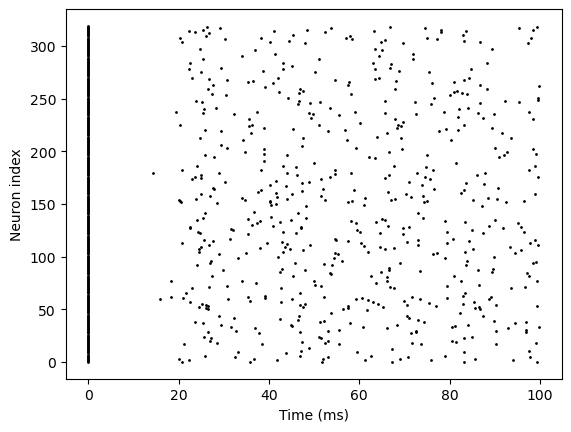

In [3]:
# instantiate EINet
net = EINet(scale=1)
# initialize DSRunner
runner = bp.DSRunner(target=net,
                     monitors=['E.spike'],
                     inputs=[('E.input', 20.), ('I.input', 20.)],
                     jit=True)
# # run the simulation
runner.run(duration=100.)
bp.visualize.raster_plot(runner.mon.ts, runner.mon['E.spike'])

In [35]:
import matplotlib.pyplot as plt
import brainpy as bp
def run(model, duration, I_ext):
  runner = bp.DSRunner(model,
                       inputs=('input', I_ext, 'iter'),
                       monitors=['V'])
  runner.run(duration)

  ts = runner.mon.ts
  fig, gs = bp.visualize.get_figure(1, 1, 4, 8)
  ax1 = fig.add_subplot(gs[0, 0])

  ax1.plot(ts, runner.mon.V[:, 0], label='V')
  # ax1.plot(ts, runner.mon.V_th[:, 0], label='V_th')
  ax1.set_xlabel('Time (ms)')
  ax1.set_ylabel('Membrane potential')
  ax1.set_xlim(-0.1, ts[-1] + 0.1)
  plt.legend()

  ax2 = ax1.twinx()
  ax2.plot(ts, I_ext, color='turquoise', label='input')
  ax2.set_xlabel('Time (ms)')
  ax2.set_ylabel('External input')
  ax2.set_xlim(-0.1, ts[-1] + 0.1)
  ax2.set_ylim(-5., 20.)
  plt.legend(loc='lower left')
  plt.show()




Predict 5000 steps: : 100%|██████████| 5000/5000 [00:00<00:00, 27545.72it/s]


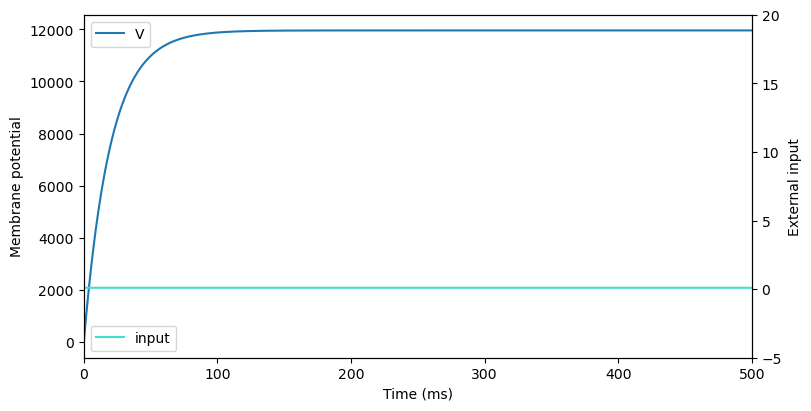

In [43]:
Iext, duration = bp.inputs.constant_input([(0.1, 500.)])
neu = bp.neurons.ALIFBellec2020(1)
run(neu, duration, Iext)